# Robust PCA
## Problem

We want to solve

$$\min\limits_{X\in\mathbb{R}^{n\times m}} f(X) + \iota_{\mathcal{C}}(X) + \iota_{[0,1]^{n\times m}}(X)$$
where 
$$\mathcal{C} = \{U\in\mathbb{R}^{n\times m}\colon \|U\|_*\leq \rho\}$$

is the set of $n\times m$ matrices with nuclear norm less than $\rho$.

We will take 

$$f(X) := \sum\limits_{i,j\in [[p,q]]}f_0(\mathcal{A}(X)_{i,j} - b_{i,j})$$

for some linear operator $\mathcal{A}\colon\mathbb{R}^{n\times m}\to \mathbb{R}^{p\times q}$ which gives us the observed pixels in the form of a subimage of size $p\times q$ and for the function $f_0\colon\mathbb{R}\to\mathbb{R}$ given by

$$f_0(x) = \frac{x^2}{2\delta^2 + x^2}$$

for some small $\delta>0$.

The derivative of $f_0$ is given by

$$f_0'(x) = \frac{4\delta^2 x}{(2\delta^2 + x^2)^2}$$

The nonsmooth function $g$ will be taken to be

$$g(X) = \iota_{[0,1]^{n\times m}}(X)$$

whose projection is just clamping componentwise to $[0,1]$.

In [64]:
import numpy as np
import fw_functions as fw

In [65]:
class RobustPCAObjective(fw.ObjectiveFunction):
    def __init__(self, delta, observed_indices_mask, observations):
        self.delta = delta
        self.observed_indices_mask = observed_indices_mask
        self.observations = observations
    
    def evaluate(self, X):
        X_observed = X[self.observed_indices_mask]
        diff = X_observed - self.observations
        return (diff**2/(2*(self.delta**2) + diff**2)).sum()
    
    def gradient(self, X):
        X_observed = X[self.observed_indices_mask]
        diff = X_observed - self.observations
        grad_observed = 4 * diff * (self.delta ** 2) / ((2 * (self.delta ** 2) + (diff ** 2)) ** 2)
        grad = np.zeros_like(X)
        grad[self.observed_indices_mask] = grad_observed
        return grad
    
    def linear_operator(self, X):
        return X
    
    def linear_operator_adjoint(self, X):
        return X
    
    def minimal_norm_selection(self, X):
        pass

In [66]:
# Create an instance of the RobustPCA objective

# Generate random data
n = int(1e2)
m = int(1e2)
X_ground_truth = np.random.rand(n,m)

p = int(8e1)
q = int(8e1)
observed_indices_mask = np.zeros((n, m), dtype=bool)
# Draw random subset of pixels
observed_indices = np.random.choice(n*m, p*q, replace=False)
rows, cols = np.unravel_index(observed_indices, (n, m))
# Set the selected pixels in the mask to True
observed_indices_mask[rows, cols] = True
observations = X_ground_truth[observed_indices_mask]


X0 = 5*np.random.rand(n,m) - 1
X0 = .9 * np.linalg.norm(X_ground_truth, ord="nuc") * X0/np.linalg.norm(X0, ord='nuc')

delta = 1.0

In [67]:
# Create the LMO function
radius = 1.1*np.linalg.norm(X_ground_truth, ord='nuc')
constraint_set = 'nuclear_norm_ball'
lmo_fn = fw.create_lmo(radius, constraint_set)

# Create the prox function
def prox_fn(X, beta):
    return fw.proj_cube(X)

# Initialize the objective
objective_fn = RobustPCAObjective(delta, observed_indices_mask, observations)
objective_type = 'indicator'

# Create an instance of the FrankWolfe class
RobustPCA = fw.FrankWolfe(objective_fn, lmo_fn, prox_fn, objective_type)

In [68]:
# Run the algorithm
sol = RobustPCA.run(X0, beta0=1.0, n_steps=int(1e5))

Frank-Wolfe Progress: 100%|██████████| 100000/100000 [07:33<00:00, 220.33it/s]


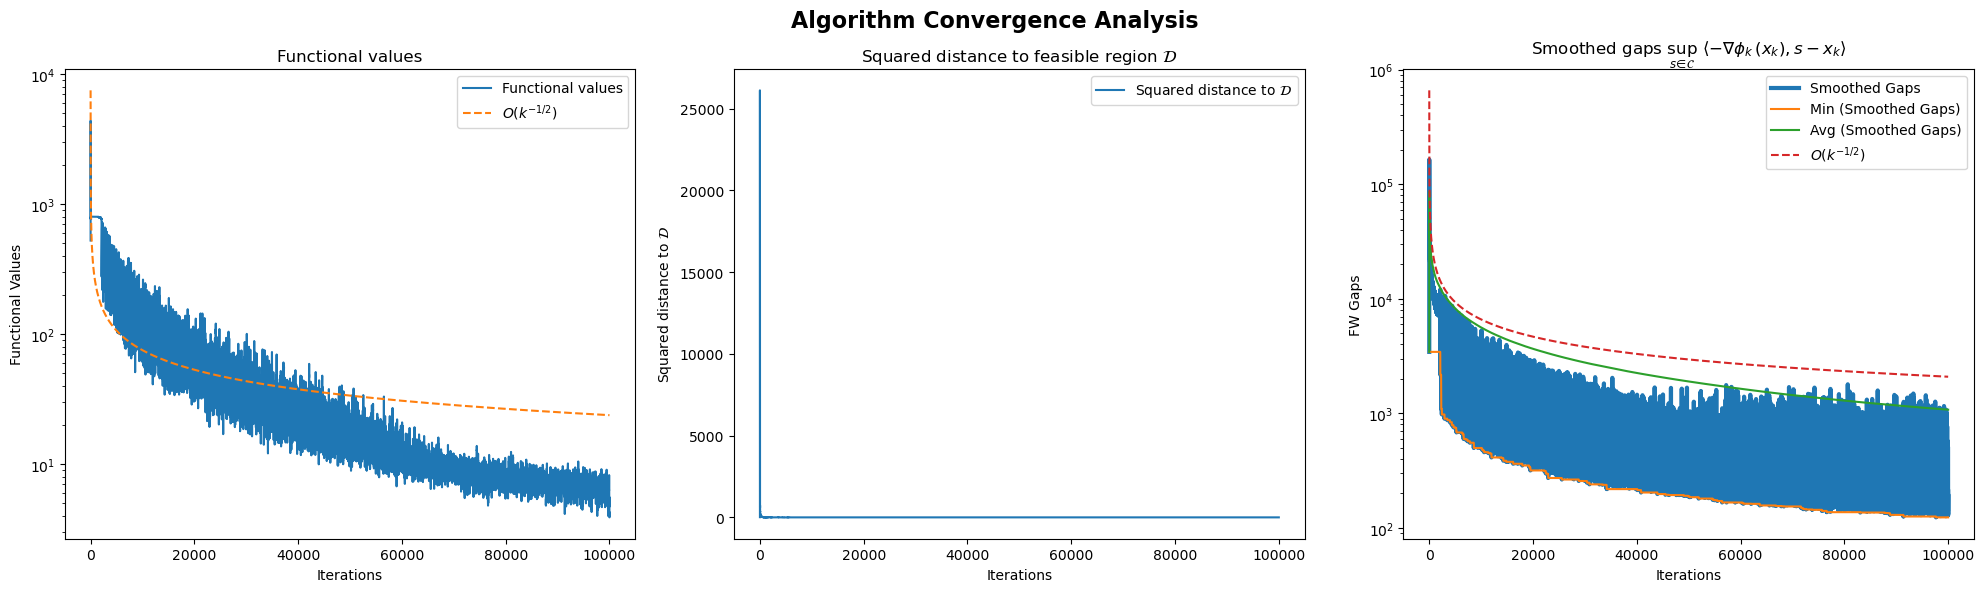

In [69]:
# Plot the convergence results
RobustPCA.plot_convergence()

In [70]:
np.linalg.norm(sol, ord='nuc')

211.58050842690827

In [71]:
np.linalg.norm(X_ground_truth, ord='nuc')

290.1445236870699